In [3]:
! pip install mne -q

In [6]:
import mne
import matplotlib.pyplot as plt

# load EDF file
file = "/kaggle/input/datasets/abhishekinnvonix/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_03.edf"
raw = mne.io.read_raw_edf(file, preload=True)

Extracting EDF parameters from /kaggle/input/datasets/abhishekinnvonix/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01/chb01_03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_55/3622147901.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file, preload=True)


In [7]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 13:43:04 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>

In [10]:
import mne
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")
base_path = "/kaggle/input/datasets/abhishekinnvonix/seizure-epilepcy-chb-mit-eeg-dataset-pediatric/chb-mit-scalp-eeg-database-1.0.0/chb01"
seizure_info = {
    "chb01_03.edf": [(2996,3036)],
    "chb01_04.edf": [(1467,1494)],
    "chb01_15.edf": [(1732,1772)],
    "chb01_16.edf": [(1015,1066)],
    "chb01_18.edf": [(1720,1810)],
    "chb01_21.edf": [(327,420)],
    "chb01_26.edf": [(1862,1963)]
}

sfreq = 256
PREICTAL_BEFORE = 35 * 60   # 35 min before seizure → preictal starts
BUFFER_BEFORE   =  5 * 60   # 5  min before seizure → preictal ends, buffer begins

interictal_segments = []
preictal_segments   = []
ictal_segments      = []

for file in sorted(os.listdir(base_path)):
    if not file.endswith(".edf"):
        continue
    file_path = os.path.join(base_path, file)
    print("Processing:", file)
    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
    data = raw.get_data()
    total_samples = data.shape[1]

    if file in seizure_info:
        for seizure_start, seizure_end in seizure_info[file]:

            start_sample = int(seizure_start * sfreq)
            end_sample   = int(seizure_end   * sfreq)

            preictal_start_sample = max(0, int((seizure_start - PREICTAL_BEFORE) * sfreq))
            preictal_end_sample   = max(0, int((seizure_start - BUFFER_BEFORE)   * sfreq))
            if preictal_end_sample > preictal_start_sample:
                preictal_segments.append(
                    data[:, preictal_start_sample:preictal_end_sample]
                )

            # Ictal segment
            ictal_segments.append(
                data[:, start_sample:end_sample]
            )

            if preictal_start_sample > 0:
                interictal_segments.append(
                    data[:, :preictal_start_sample]
                )
            if end_sample < total_samples:
                interictal_segments.append(
                    data[:, end_sample:]
                )
    else:
        interictal_segments.append(data)

interictal_data = np.concatenate(interictal_segments, axis=1)
preictal_data   = np.concatenate(preictal_segments,   axis=1)
ictal_data      = np.concatenate(ictal_segments,      axis=1)

print("\nFinal dataset shapes")
print("Interictal:", interictal_data.shape)
print("Preictal:  ", preictal_data.shape)
print("Ictal:     ", ictal_data.shape)

np.save("chb01_interictal.npy", interictal_data)
np.save("chb01_preictal.npy",   preictal_data)
np.save("chb01_ictal.npy",      ictal_data)
print("\nSaved numpy arrays.")

Processing: chb01_01.edf
Processing: chb01_02.edf
Processing: chb01_03.edf
Processing: chb01_04.edf
Processing: chb01_05.edf
Processing: chb01_06.edf
Processing: chb01_07.edf
Processing: chb01_08.edf
Processing: chb01_09.edf
Processing: chb01_10.edf
Processing: chb01_11.edf
Processing: chb01_12.edf
Processing: chb01_13.edf
Processing: chb01_14.edf
Processing: chb01_15.edf
Processing: chb01_16.edf
Processing: chb01_17.edf
Processing: chb01_18.edf
Processing: chb01_19.edf
Processing: chb01_20.edf
Processing: chb01_21.edf
Processing: chb01_22.edf
Processing: chb01_23.edf
Processing: chb01_24.edf
Processing: chb01_25.edf
Processing: chb01_26.edf
Processing: chb01_27.edf
Processing: chb01_29.edf
Processing: chb01_30.edf
Processing: chb01_31.edf
Processing: chb01_32.edf
Processing: chb01_33.edf
Processing: chb01_34.edf
Processing: chb01_36.edf
Processing: chb01_37.edf
Processing: chb01_38.edf
Processing: chb01_39.edf
Processing: chb01_40.edf
Processing: chb01_41.edf
Processing: chb01_42.edf


In [41]:
print("Interictal segments:")
for i, chunk in enumerate(interictal_segments):
    print(f"  chunk {i} : {chunk.shape}")

print("\nPreictal segments:")
for i, chunk in enumerate(preictal_segments):
    print(f"  chunk {i} : {chunk.shape}")

print("\nIctal segments:")
for i, chunk in enumerate(ictal_segments):
    print(f"  chunk {i} : {chunk.shape}")

Interictal segments:
  chunk 0 : (23, 921600)
  chunk 1 : (23, 921600)
  chunk 2 : (23, 229376)
  chunk 3 : (23, 144384)
  chunk 4 : (23, 539136)
  chunk 5 : (23, 921600)
  chunk 6 : (23, 921600)
  chunk 7 : (23, 921600)
  chunk 8 : (23, 921600)
  chunk 9 : (23, 921600)
  chunk 10 : (23, 921600)
  chunk 11 : (23, 921600)
  chunk 12 : (23, 921600)
  chunk 13 : (23, 921600)
  chunk 14 : (23, 921600)
  chunk 15 : (23, 467968)
  chunk 16 : (23, 648704)
  chunk 17 : (23, 921600)
  chunk 18 : (23, 458240)
  chunk 19 : (23, 921600)
  chunk 20 : (23, 681728)
  chunk 21 : (23, 814080)
  chunk 22 : (23, 921600)
  chunk 23 : (23, 921600)
  chunk 24 : (23, 921600)
  chunk 25 : (23, 921600)
  chunk 26 : (23, 92672)
  chunk 27 : (23, 153600)
  chunk 28 : (23, 921600)
  chunk 29 : (23, 921600)
  chunk 30 : (23, 921600)
  chunk 31 : (23, 921600)
  chunk 32 : (23, 921600)
  chunk 33 : (23, 921600)
  chunk 34 : (23, 921600)
  chunk 35 : (23, 921600)
  chunk 36 : (23, 921600)
  chunk 37 : (23, 921600)
  

In [45]:
WIN_SAMP  = 4 * 256 
STEP_SAMP = 2*256
def extract_windows(segment, win_samp, step_samp):
    windows = []
    n = segment.shape[1]
    for start in range(0, n - win_samp + 1, step_samp):
        windows.append(segment[:, start:start + win_samp])
    return windows
interictal_windows = []
for chunk in interictal_segments:
    interictal_windows.extend(extract_windows(chunk, WIN_SAMP, STEP_SAMP))

preictal_windows = []
for chunk in preictal_segments:
    preictal_windows.extend(extract_windows(chunk, WIN_SAMP, STEP_SAMP))

ictal_windows = []
for chunk in ictal_segments:
    ictal_windows.extend(extract_windows(chunk, WIN_SAMP, STEP_SAMP))

print(f"Interictal windows : {len(interictal_windows)}")
print(f"Preictal windows   : {len(preictal_windows)}")
print(f"Ictal windows      : {len(ictal_windows)}")

Interictal windows : 67618
Preictal windows   : 4053
Ictal windows      : 212


In [46]:
import numpy as np

rng = np.random.default_rng(42)

N_ICT = len(ictal_windows) 
interictal_windows = np.array(interictal_windows)  
preictal_windows   = np.array(preictal_windows)    
ictal_windows      = np.array(ictal_windows) 
idx_int = rng.choice(len(interictal_windows), size=N_ICT * 5, replace=False)
interictal_windows = interictal_windows[idx_int]
idx_pre = rng.choice(len(preictal_windows), size=N_ICT * 2, replace=False)
preictal_windows = preictal_windows[idx_pre]

print(f"After balancing:")
print(f"Interictal windows : {len(interictal_windows)}")  
print(f"Preictal windows   : {len(preictal_windows)}") 
print(f"Ictal windows      : {len(ictal_windows)}") 

After balancing:
Interictal windows : 1060
Preictal windows   : 424
Ictal windows      : 212


In [47]:
from scipy.stats import skew, kurtosis
import numpy as np

def extract_features_window(window):
    feats = []
    for ch in range(window.shape[0]):      # iterate each channel
        sig = window[ch]
        feats.append(np.mean(np.abs(sig))) # mean absolute amplitude
        feats.append(np.std(sig))          # standard deviation
        feats.append(np.max(np.abs(sig)))  # max absolute value
        feats.append(np.ptp(sig))          # peak to peak
        feats.append(skew(sig))            # skewness
        feats.append(kurtosis(sig))        # kurtosis
    return np.array(feats, dtype=np.float32)  

In [48]:
X_int = np.array([extract_features_window(w) for w in interictal_windows])  
X_pre = np.array([extract_features_window(w) for w in preictal_windows])
X_ict = np.array([extract_features_window(w) for w in ictal_windows])       

In [49]:
y_int = np.zeros(len(X_int), dtype=np.int8)      # [0, 0, 0, ...]
y_pre = np.ones(len(X_pre),  dtype=np.int8)      # [1, 1, 1, ...]
y_ict = np.full(len(X_ict),  2, dtype=np.int8)   # [2, 2, 2, ...]

# Combine
X = np.vstack([X_int, X_pre, X_ict])             # (1696, 138)
y = np.concatenate([y_int, y_pre, y_ict])        # (1696,)

# Shuffle
rng  = np.random.default_rng(42)
perm = rng.permutation(len(X))
X, y = X[perm], y[perm]


In [50]:
print(f"X shape : {X.shape}")   # (1696, 138)
print(f"y shape : {y.shape}")   # (1696,)
print(f"\nClass counts:")
print(f"  Interictal (0) : {np.sum(y==0)}")
print(f"  Preictal   (1) : {np.sum(y==1)}")
print(f"  Ictal      (2) : {np.sum(y==2)}")
print(f"\nSample row (first window features):")
print(f"  {X[0]}")
print(f"  Label : {y[0]}")

X shape : (1696, 138)
y shape : (1696,)

Class counts:
  Interictal (0) : 1060
  Preictal   (1) : 424
  Ictal      (2) : 212

Sample row (first window features):
  [ 2.8360042e-05  7.2572700e-05  5.2141637e-04  6.9274724e-04
  4.1021514e+00  2.5620937e+01  1.2816698e-05  2.0085670e-05
  1.2522588e-04  1.7621489e-04  2.7085111e+00  1.3035478e+01
  1.1512897e-05  1.4539598e-05  5.2551892e-05  9.9242978e-05
  1.4072223e-01  2.5807577e-01  1.0012973e-05  1.3036057e-05
  5.0598290e-05  9.3382172e-05  2.4504359e-01  6.4309257e-01
  3.0299909e-05  7.4600575e-05  5.3001218e-04  7.0290599e-04
  3.9503307e+00  2.4586157e+01  2.4711157e-05  3.2092816e-05
  1.2717949e-04  2.1645910e-04  2.8786644e-01  5.5193001e-01
  5.4017477e-05  6.4800690e-05  1.7484737e-04  3.0827840e-04
  3.9817572e-01 -6.6996050e-01  5.9249847e-05  7.3184849e-05
  2.0766789e-04  3.9072038e-04 -3.6625612e-01 -4.0791944e-01
  3.0148809e-05  5.7934783e-05  3.7841269e-04  5.2630034e-04
  3.3031754e+00  1.8402000e+01  1.7240538e-

In [51]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ── SCALE ──────────────────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── MODELS ─────────────────────────────────────────────────────────────────────
models = {
    "SVM (RBF)"        : SVC(kernel="rbf", C=10, gamma="scale",
                             class_weight="balanced", random_state=42),
    "Random Forest"    : RandomForestClassifier(n_estimators=200, max_depth=15,
                                                class_weight="balanced",
                                                random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                                     learning_rate=0.05,
                                                     random_state=42),
}

# ── CROSS VALIDATION ───────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 55)
print("        5-Fold Stratified Cross Validation")
print("=" * 55)

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y,
                             cv=cv, scoring="f1_macro", n_jobs=-1)
    cv_results[name] = scores
    print(f"\n{name}")
    print(f"  F1 per fold : {[round(s,3) for s in scores]}")
    print(f"  Mean F1     : {scores.mean():.4f}")
    print(f"  Std         : {scores.std():.4f}")

print("\n" + "=" * 55)

        5-Fold Stratified Cross Validation

SVM (RBF)
  F1 per fold : [np.float64(0.881), np.float64(0.873), np.float64(0.867), np.float64(0.881), np.float64(0.861)]
  Mean F1     : 0.8726
  Std         : 0.0079

Random Forest
  F1 per fold : [np.float64(0.852), np.float64(0.858), np.float64(0.839), np.float64(0.9), np.float64(0.841)]
  Mean F1     : 0.8580
  Std         : 0.0220

Gradient Boosting
  F1 per fold : [np.float64(0.859), np.float64(0.874), np.float64(0.83), np.float64(0.882), np.float64(0.865)]
  Mean F1     : 0.8619
  Std         : 0.0176



In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train/Test split:")
print(f"  Train : {len(X_train)}  Test : {len(X_test)}")
print(f"\n  Train class counts → int:{np.sum(y_train==0)}  "
      f"pre:{np.sum(y_train==1)}  ict:{np.sum(y_train==2)}")
print(f"  Test  class counts → int:{np.sum(y_test==0)}  "
      f"pre:{np.sum(y_test==1)}  ict:{np.sum(y_test==2)}")

CLASS_NAMES = ["Interictal", "Preictal", "Ictal"]

print("\n" + "=" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                target_names=CLASS_NAMES))

Train/Test split:
  Train : 1356  Test : 340

  Train class counts → int:847  pre:339  ict:170
  Test  class counts → int:213  pre:85  ict:42


  SVM (RBF)
              precision    recall  f1-score   support

  Interictal       0.93      0.84      0.88       213
    Preictal       0.68      0.85      0.75        85
       Ictal       1.00      1.00      1.00        42

    accuracy                           0.86       340
   macro avg       0.87      0.90      0.88       340
weighted avg       0.88      0.86      0.87       340


  Random Forest
              precision    recall  f1-score   support

  Interictal       0.88      0.92      0.90       213
    Preictal       0.78      0.69      0.73        85
       Ictal       0.98      0.95      0.96        42

    accuracy                           0.87       340
   macro avg       0.88      0.86      0.87       340
weighted avg       0.87      0.87      0.87       340


  Gradient Boosting
              precision    recall  f1-score 

Conclusion :
Subject Specific ML model using Mean,Std,Skew,Max,P2P,Kurtosis(6 features per channel).
Windows of size 4 sec with 50% overlap are considered and duration of [-35,-5] considered as preictal duration.
Trained 3 models  SVM,RF,Graditing Boosting.
SVM(rbf) emergerd as the best model with F1 Cross Validation F1 Score of 87% 
This is model is able to predict ictal with 100% accuracy with and 100% recall.
but with low accuracy of 68% and recall 85% for preictal state that means there are many false alarms at preictal state
the issue can be as we are considering -35 mins for start of preictal state we can have a closer relation ship to the interictal state so change preictal duration less 30 min can help,other ways for improving this can perform band pass filtering and considering frequencies only upto 40Hz and using band powers as linear features.


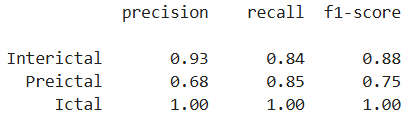

In [53]:
import numpy as np

np.save("X_features.npy", X)
np.save("y_labels.npy", y)

print(f"Saved X : {X.shape}")
print(f"Saved y : {y.shape}")

Saved X : (1696, 138)
Saved y : (1696,)
